In [8]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torch.utils.data import random_split
from torchvision import datasets, transforms

In [2]:
import kagglehub

path = kagglehub.dataset_download("asdasdasasdas/garbage-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'garbage-classification' dataset.
Path to dataset files: /kaggle/input/garbage-classification


In [7]:
transform_train = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

transform_test = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

data_dir = os.path.join(path, 'Garbage classification/Garbage classification')

full_data = datasets.ImageFolder(root=data_dir, transform=transform_train)
class_names = full_data.classes
print("Классы:", class_names)
print("Всего изображений:", len(full_data))

Классы: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Всего изображений: 2527


In [9]:
train_size = int(0.8 * len(full_data))
test_size  = len(full_data) - train_size
train_data, test_data = random_split(full_data, [train_size, test_size])

# Для test_data применяем transform_test
test_data.dataset.transform = transform_test

train = DataLoader(train_data, batch_size=32, shuffle=True)
test  = DataLoader(test_data,  batch_size=32)

print(f"Train: {train_size} | Test: {test_size}")

Train: 2021 | Test: 506


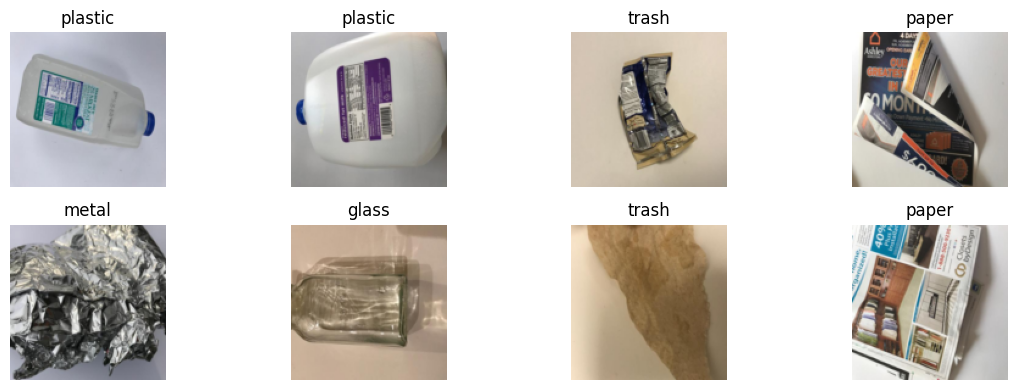

In [10]:
images, labels = next(iter(train))

plt.figure(figsize=(12, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    img = images[i].permute(1, 2, 0) * 0.5 + 0.5  # денормализация
    plt.imshow(img.clamp(0, 1))
    plt.title(class_names[labels[i]])
    plt.axis('off')
plt.tight_layout()
plt.savefig('sample_images.png')
plt.show()

In [11]:
class GarbageClassifier(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

Device: cuda


In [13]:
model = GarbageClassifier(num_classes=6).to(device)

In [14]:
loss_fn   = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [18]:
for epoch in range(60):
    model.train()
    total_loss = 0
    for x_batch, y_batch in train:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        y_pred = model(x_batch)
        loss   = loss_fn(y_pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f'Эпоха {epoch + 1:02d} -- Потери: {round(total_loss, 2)}')

Эпоха 01 -- Потери: 25.04
Эпоха 02 -- Потери: 18.76
Эпоха 03 -- Потери: 18.17
Эпоха 04 -- Потери: 17.05
Эпоха 05 -- Потери: 21.86
Эпоха 06 -- Потери: 23.76
Эпоха 07 -- Потери: 17.71
Эпоха 08 -- Потери: 16.81
Эпоха 09 -- Потери: 16.42
Эпоха 10 -- Потери: 15.9
Эпоха 11 -- Потери: 15.99
Эпоха 12 -- Потери: 16.44
Эпоха 13 -- Потери: 14.09
Эпоха 14 -- Потери: 12.78
Эпоха 15 -- Потери: 14.13
Эпоха 16 -- Потери: 14.79
Эпоха 17 -- Потери: 20.77
Эпоха 18 -- Потери: 17.17
Эпоха 19 -- Потери: 13.08
Эпоха 20 -- Потери: 11.94
Эпоха 21 -- Потери: 11.85
Эпоха 22 -- Потери: 11.05
Эпоха 23 -- Потери: 10.56
Эпоха 24 -- Потери: 12.21
Эпоха 25 -- Потери: 12.37
Эпоха 26 -- Потери: 11.84
Эпоха 27 -- Потери: 13.13
Эпоха 28 -- Потери: 12.96
Эпоха 29 -- Потери: 10.49
Эпоха 30 -- Потери: 10.89
Эпоха 31 -- Потери: 10.43
Эпоха 32 -- Потери: 10.13
Эпоха 33 -- Потери: 11.81
Эпоха 34 -- Потери: 10.92
Эпоха 35 -- Потери: 9.75
Эпоха 36 -- Потери: 9.63
Эпоха 37 -- Потери: 10.9
Эпоха 38 -- Потери: 9.09
Эпоха 39 -- Потер

In [19]:
model.eval()
correct = 0
total   = 0

with torch.no_grad():
    for x_batch, y_batch in test:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        y_pred     = model(x_batch)
        prediction = torch.argmax(y_pred, dim=1)
        total     += y_batch.size(0)
        correct   += (prediction == y_batch).sum().item()

accuracy = correct * 100 / total
print(f'Точность на тестовых данных: {round(accuracy, 2)}%')

Точность на тестовых данных: 69.96%


In [21]:
from google.colab import files

torch.save(class_names, 'labels_GarbageClassification.pth')
torch.save(model.state_dict(), 'model_GarbageClassification.pth')

files.download('labels_GarbageClassification.pth')
files.download('model_GarbageClassification.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>